### Isolation Forest Experiment
This first experiment explores the performance of a simple isolation forest on the features used in RELAISS. We extract RELAISS features from codebase and explore how often the anomalies are in a low minority class. This indicates how the isolation forest is performing

Using 03_build_databank notebook to extract RELAISS features

**Goal:** Use Isolation Forest to detect anomalies in the dataset and interpret which observations are likely outliers.

**Isolation Forest:** It isolates points by randomly selecting features and split values; anomalies are easier to isolate (fewer split lines). 


In [1]:
import os
import pandas as pd
import numpy as np
from relaiss import constants
import relaiss as rl
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

In [114]:
csv_path = "/Users/jennakempster-taylor/re-laiss/reference_20k.csv" 

# Load
df = pd.read_csv(csv_path, low_memory=False)

# Ensure there is an object name column
if "objName" not in df.columns:
    # Some variants may include "NAME" or similar; map it if present
    for candidate in ["NAME", "name", "ObjName", "object_name"]:
        if candidate in df.columns:
            df = df.rename(columns={candidate: "objName"})
            break

if "objName" not in df.columns:
    raise ValueError("Could not find 'objName' in the CSV. ")

print("Shape:", df.shape)
print("Columns:", df.columns[:10])  # first 10 columns
print("First few objNames:", df["objName"].head())


Shape: (25515, 458)
Columns: Index(['t0', 'g_peak_mag', 'g_peak_time', 'g_rise_time', 'g_decline_time',
       'g_duration_above_half_flux', 'g_amplitude', 'g_skewness',
       'g_beyond_2sigma', 'r_peak_mag'],
      dtype='object')
First few objNames: 0    PSO J032.5595-01.8136
1    PSO J118.7364+35.9410
2    PSO J158.8836+37.6496
3    PSO J031.2821+11.2486
4    PSO J105.8641+32.0687
Name: objName, dtype: object


In [115]:
# Grab our RELAISS features
default_lc_features = constants.lc_features_const.copy()
default_host_features = constants.host_features_const.copy()

# quick look at what is included
print("Default LC features (sample):", default_lc_features[:10])
print("Default host features (sample):", default_host_features[:10])


Default LC features (sample): ['g_peak_time', 'r_peak_time', 'g_rise_time', 'g_decline_time', 'r_rise_time', 'r_decline_time', 'g_duration_above_half_flux', 'r_duration_above_half_flux', 'g_amplitude', 'r_amplitude']
Default host features (sample): ['gKronMagCorrected', 'gKronRad', 'gExtNSigma', 'rKronMagCorrected', 'rKronRad', 'rExtNSigma', 'iKronMagCorrected', 'iKronRad', 'iExtNSigma', 'zKronMagCorrected']


Double check the default RELAISS features are all in our csv file:

In [116]:
from pprint import pprint

USE_HOST = False  # use only light curves initially

def overlap(cols, frame):
    return [c for c in cols if (c in frame.columns) and (not c.endswith("_err"))]

lc_cols   = overlap(default_lc_features, df)
host_cols = overlap(default_host_features, df) if USE_HOST else []

feature_cols = lc_cols + host_cols

print(f"Found {len(lc_cols)} LC features in CSV.")
if USE_HOST:
    print(f"Found {len(host_cols)} host features in CSV.")
print(f"Total features used: {len(feature_cols)}")
pprint(feature_cols)


Found 25 LC features in CSV.
Total features used: 25
['g_peak_time',
 'r_peak_time',
 'g_rise_time',
 'g_decline_time',
 'r_rise_time',
 'r_decline_time',
 'g_duration_above_half_flux',
 'r_duration_above_half_flux',
 'g_amplitude',
 'r_amplitude',
 'g_skewness',
 'r_skewness',
 'g_beyond_2sigma',
 'r_beyond_2sigma',
 'mean_g-r',
 'g-r_at_g_peak',
 'mean_color_rate',
 'g_max_rolling_variance',
 'r_max_rolling_variance',
 'g_mean_rolling_variance',
 'r_mean_rolling_variance',
 'g_rise_local_curvature',
 'g_decline_local_curvature',
 'r_rise_local_curvature',
 'r_decline_local_curvature']


Start cleaning data: \
Might be missing or NaNs 

### Filtering Out Likely Stellar Variables (Alert-Span Cut)

Before fitting the Isolation Forest, we remove objects whose alert duration (time between their newest and oldest alert)
is **less than 200 days**.

**Rationale:**  
Short-duration alert spans are often due to periodic or short-lived variability (e.g., variable stars), rather than true
transient or extragalactic anomalies. These objects can dominate the anomaly set and bias the Isolation Forest toward
identifying variable stars instead of interesting astrophysical transients.

**Implementation:**  
We calculate each object's alert span as:

\[
\Delta t = \text{newest\_alert} - \text{oldest\_alert}
\]

and only keep those with Δt ≥ 200 days.  



In [120]:
# accept either datetime columns or numeric day counts (e.g., MJD already in days).
REQUIRED = {"newest_alert", "oldest_alert"}
missing = REQUIRED - set(map(str.lower, df.columns.str.lower()))

if missing:
    raise ValueError(f"Missing required columns for span filter: {missing}. "
                     "Expected columns 'newest_alert' and 'oldest_alert' (case-insensitive).")

# Resolve actual column names in case of case/format differences
def _find(col):
    return next(c for c in df.columns if c.lower() == col)

newest_col = _find("newest_alert")
oldest_col = _find("oldest_alert")

newest = df[newest_col]
oldest = df[oldest_col]


if not np.issubdtype(newest.dtype, np.number) or not np.issubdtype(oldest.dtype, np.number):
    newest = pd.to_datetime(newest, errors="coerce", utc=True)
    oldest = pd.to_datetime(oldest, errors="coerce", utc=True)
    span_days = (newest - oldest).dt.total_seconds() / 86400.0
else:
    
    span_days = newest - oldest

df["alert_span_days"] = span_days

# Keep only rows with span < 200 days (and a finite span)
mask_span = df["alert_span_days"].apply(np.isfinite) & (df["alert_span_days"] < 200)
before, after = len(df), int(mask_span.sum())
print(f"Applying alert-span < 200d: kept {after}/{before} rows ({after/before:.1%}).")

# Apply the cut to df
df = df.loc[mask_span].reset_index(drop=True)



Applying alert-span < 200d: kept 1342/25515 rows (5.3%).


In [124]:
from sklearn.impute import SimpleImputer

X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

# Quick look at missingness
missing_pct = X.isna().mean().sort_values(ascending=False)
print("Top 10 columns by missing rate:")
print(missing_pct.head(10))


Top 10 columns by missing rate:
g_rise_local_curvature        0.419192
g_decline_local_curvature     0.308081
r_decline_local_curvature     0.292929
r_rise_local_curvature        0.262626
g_rise_time                   0.247475
r_decline_time                0.171717
g_decline_time                0.141414
r_rise_time                   0.126263
g_duration_above_half_flux    0.090909
g_peak_time                   0.065657
dtype: float64
X shape: (198, 25)  -> after impute: (1342, 25)


A lot of missing data here ~40%, so use KNN imputation. 

In [126]:
from sklearn.impute import KNNImputer

X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

#  missing value is filled in using  mean of 5 nearest neighbors
knn_imp = KNNImputer(n_neighbors=5, weights="uniform")
X_imp = knn_imp.fit_transform(X)

print("X shape:", X.shape, " -> after KNN impute:", X_imp.shape)

X shape: (198, 25)  -> after KNN impute: (198, 25)


### Isolation Forest:

In [128]:
iso = IsolationForest(
    n_estimators=300,
    contamination="auto",   # use auto for first run
    random_state=42,
    n_jobs=-1
)
iso.fit(X_imp)

scores   = iso.decision_function(X_imp)  # higher = more normal
raw_pred = iso.predict(X_imp)            # -1 anomaly, 1 normal
anomaly  = (raw_pred == -1).astype(int)  # 1 = anomaly

rank = pd.Series(scores).rank(method="first", ascending=True).astype(int)  # 1 = most anomalous

print("Estimated anomaly rate:", anomaly.mean())

Estimated anomaly rate: 0.0707070707070707


In [130]:
out = pd.DataFrame({
    "ZTFID": df["ZTFID"].values,
    "r_duration_above_half_flux": df["r_duration_above_half_flux"].values,
    "iso_score": scores,
    "iso_anomaly": anomaly,
    "iso_rank": rank
    
})

# Optional context columns if present
context_cols = [c for c in ["t0","r_duration_above_half_flux", "g_peak_mag","r_peak_mag","mean_g-r","features_valid"] if c in df.columns]
preview = pd.concat([df[["ZTFID"] + context_cols].reset_index(drop=True),
                     out[["r_duration_above_half_flux","iso_score","iso_anomaly","iso_rank"]]], axis=1)

# Show 10 most anomalous
display(preview.sort_values("iso_rank").head(10))


,ZTFID,t0,r_duration_above_half_flux,g_peak_mag,r_peak_mag,mean_g-r,features_valid,r_duration_above_half_flux,iso_score,iso_anomaly,iso_rank
60,ZTF25aacfjde,60694.403900,NaN,13.371340,12.851389,-0.020231,False,NaN,-0.203468,1,1
68,ZTF25aaguzft,60729.381088,4.882697,14.344838,12.518044,-0.076079,False,4.882697,-0.154025,1,2
135,ZTF19aatetvk,60687.504329,107.749815,16.118999,15.341308,1.039580,True,107.749815,-0.092497,1,3
39,ZTF25aacawwc,60687.504329,110.784769,18.313494,18.376299,0.108517,True,110.784769,-0.070387,1,4
78,ZTF18aavedgv,60705.556701,83.865428,17.900801,15.723200,2.090896,False,83.865428,-0.055108,1,5
184,ZTF18abkjynl,60690.576412,82.857512,18.055931,14.950493,3.146611,True,82.857512,-0.050015,1,6
36,ZTF25aafdpuq,60705.383472,92.923981,19.299000,20.123993,0.170617,False,92.923981,-0.038322,1,7
123,ZTF18abvhkxb,60687.569618,17.943704,16.759636,15.056261,1.635746,False,17.943704,-0.034974,1,8
92,ZTF18admfslu,60687.577720,4.005799,17.286301,15.045146,2.117016,False,4.005799,-0.031740,1,9
14,ZTF25aadgdlk,60692.517211,96.875440,19.968300,19.929701,0.377139,False,96.875440,-0.024455,1,10


In [144]:
import io, sys, requests
import pandas as pd

# top 10
ztfids = [
    "ZTF25aacfjde","ZTF25aaguzft","ZTF19aatetvk","ZTF25aacawwc","ZTF18aavedgv",
    "ZTF18abkjynl","ZTF25aafdpuq","ZTF18abvhkxb","ZTF18admfslu","ZTF25aadgdlk"
]

# BTS CSV query 
bts_csv_url = ("https://sites.astro.caltech.edu/ztf/bts/explorer.php?f=s&subsample=all&classstring=&classexclude=&quality=y&ztflink=lasair&lastdet=&startsavedate=&startpeakdate=&startra=&startdec=&startz=&startdur=&startrise=&startfade=&startpeakmag=&startabsmag=&starthostabs=&starthostcol=&startb=&startav=&endsavedate=&endpeakdate=&endra=&enddec=&endz=&enddur=&endrise=&endfade=&endpeakmag=19.0&endabsmag=&endhostabs=&endhostcol=&endb=&endav=&format=csv")

# polite headers help if a site blocks default clients
headers = {"User-Agent": "python-requests/2.x (research use)"}
r = requests.get(bts_csv_url, headers=headers, timeout=60)
r.raise_for_status()

# Load CSV into DataFrame (ZTF ID column name is exactly 'ZTF ID' per BTS docs)
bts = pd.read_csv(io.StringIO(r.text))
# Force string dtype for safety
bts["ZTFID"] = bts["ZTFID"].astype(str)

# Filter rows to your ZTF IDs
subset = bts[bts["ZTFID"].isin(ztfids)].copy()

# Keep the most useful columns (tweak as you like)
keep_cols = ["ZTFID","TNS ID","Type","Redshift","time","mag","Duration","Rise","Fade"]
subset = subset[[c for c in keep_cols if c in subset.columns]]

print(f"Matched {len(subset)}/{len(ztfids)} of your objects in BTS.")
display(subset)


Matched 0/10 of your objects in BTS.


,ZTFID


In [148]:
import io, requests, pandas as pd
ids = ["ZTF25aacfjde","ZTF25aaguzft","ZTF19aatetvk","ZTF25aacawwc","ZTF18aavedgv",
       "ZTF18abkjynl","ZTF25aafdpuq","ZTF18abvhkxb","ZTF18admfslu","ZTF25aadgdlk"]

r = requests.post(
    "https://api.fink-portal.org/api/v1/objects",
    json={"objectId": ",".join(ids), "output-format": "json"},
    timeout=90,
)
pdf = pd.read_json(io.BytesIO(r.content))

# Many alerts per object. 'v:classification' holds Fink’s label per alert.
if "v:classification" not in pdf.columns:
    print("No Fink classifications returned; inspect columns:", pdf.columns.tolist())

# Summarize to object-level label by majority vote (excluding 'Unknown')
def summarize(df):
    sub = df[df["v:classification"] != "Unknown"]
    if len(sub) == 0:
        return pd.Series({"fink_class": "Unknown", "support": 0.0, "n_alerts": len(df)})
    top = sub["v:classification"].value_counts(normalize=True).idxmax()
    frac = sub["v:classification"].value_counts(normalize=True).max()
    return pd.Series({"fink_class": top, "support": float(frac), "n_alerts": len(df)})

summary = pdf.groupby("i:objectId").apply(summarize).reset_index().rename(columns={"i:objectId":"ZTFID"})
summary.sort_values(["fink_class","support"], ascending=[True, False])



,ZTFID,fink_class,support,n_alerts
2,ZTF18abvhkxb,Candidate_LP*,0.388128,445
9,ZTF25aaguzft,CataclyV*,1.000000,24
0,ZTF18aavedgv,LongPeriodV*,0.769231,219
3,ZTF18admfslu,LongPeriodV*,0.473333,153
5,ZTF25aacawwc,SN candidate,1.000000,41
4,ZTF19aatetvk,Unknown,0.000000,64
7,ZTF25aadgdlk,Unknown,0.000000,8
8,ZTF25aafdpuq,Unknown,0.000000,18
1,ZTF18abkjynl,V*,0.584270,277
6,ZTF25aacfjde,WhiteDwarf_Candidate,1.000000,50


### Supernova Prefilters (Amplitude, Duration)

To focus our Isolation Forest on supernova-like events (and suppress stellar variables), apply simple, physically-motivated cuts **before** model fitting:

- **Amplitude:** max(Δmag\_g, Δmag\_r) > **1.0 mag**  
  Supernovae exhibit larger brightness changes than most stellar variables.

- **Alert duration:** **5–120 days**  
  SNe evolve on week-to-month timescales; very short events and very long, persistent variables are filtered out.

These are conservative defaults you can tune. After these prefilters, we rebuild the feature matrix and fit the Isolation Forest on a cleaner, SN-like subset.


In [136]:
# Grab our RELAISS features
default_lc_features = constants.lc_features_const.copy()
default_host_features = constants.host_features_const.copy()


USE_HOST = False  # use only light curves initially

def overlap(cols, frame):
    return [c for c in cols if (c in frame.columns) and (not c.endswith("_err"))]

lc_cols   = overlap(default_lc_features, df)
host_cols = overlap(default_host_features, df) if USE_HOST else []

feature_cols = lc_cols + host_cols

REQUIRED = {"newest_alert", "oldest_alert"}
missing = REQUIRED - set(map(str.lower, df.columns.str.lower()))

if missing:
    raise ValueError(f"Missing required columns for span filter: {missing}. "
                     "Expected columns 'newest_alert' and 'oldest_alert' (case-insensitive).")

# Resolve actual column names in case of case/format differences
def _find(col):
    return next(c for c in df.columns if c.lower() == col)

newest_col = _find("newest_alert")
oldest_col = _find("oldest_alert")

newest = df[newest_col]
oldest = df[oldest_col]

# If they look like datetimes, convert; otherwise treat as numeric days (e.g., MJD)
if not np.issubdtype(newest.dtype, np.number) or not np.issubdtype(oldest.dtype, np.number):
    newest = pd.to_datetime(newest, errors="coerce", utc=True)
    oldest = pd.to_datetime(oldest, errors="coerce", utc=True)
    span_days = (newest - oldest).dt.total_seconds() / 86400.0
else:
    # Numeric already in "days" (typical for MJD); if it's MJD this is exactly days.
    span_days = newest - oldest

df["alert_span_days"] = span_days

# Keep only rows with span < 200 days (and a finite span)
mask_span = df["alert_span_days"].apply(np.isfinite) & (df["alert_span_days"] < 200)
before, after = len(df), int(mask_span.sum())
print(f"Applying alert-span < 200d: kept {after}/{before} rows ({after/before:.1%}).")

# Apply the cut to df
df = df.loc[mask_span].reset_index(drop=True)

Applying alert-span < 200d: kept 198/198 rows (100.0%).


In [138]:
# ---- need to reload ----
import numpy as np
import pandas as pd

# Thresholds (open to tuning here)
AMPLITUDE_MIN = 1.0          # mag
SPAN_MIN_DAYS = 5.0
SPAN_MAX_DAYS = 200.0


required_cols = {
    "g_amplitude": None,
    "r_amplitude": None,
    "alert_span_days": None,   # from your earlier alert-span cell
}
optional_cols = {
    "mean_g-r": None,          # colour cut
}

# Resolve actual column names case-insensitively
def find_col(name, cols):
    for c in df.columns:
        if c.lower() == name.lower():
            return c
    return None

for k in list(required_cols.keys()):
    required_cols[k] = find_col(k, df.columns)

for k in list(optional_cols.keys()):
    optional_cols[k] = find_col(k, df.columns)

missing = [k for k, v in required_cols.items() if v is None]
if missing:
    raise KeyError(
        "Missing required columns for SN-like prefilters: "
        + ", ".join(missing)
        + ". Make sure previous cells created/kept these features."
    )

# Compute helper quantities
g_amp = df[required_cols["g_amplitude"]]
r_amp = df[required_cols["r_amplitude"]]
span  = df[required_cols["alert_span_days"]]

# Robust amplitude: row-wise max across available bands (NaNs handled)
amp_max = pd.concat([g_amp, r_amp], axis=1).max(axis=1, skipna=True) 

# Build boolean mask
mask = (
    amp_max.gt(AMPLITUDE_MIN) # max amplt greater than 1 (diff of g r)
    & span.ge(SPAN_MIN_DAYS)
    & span.le(SPAN_MAX_DAYS)
)

# Optional colour cut
if USE_COLOUR_CUT and optional_cols["mean_g-r"] is not None:
    colour = df[optional_cols["mean_g-r"]]
    mask &= colour.gt(COLOUR_MIN)

# Report and filter
before = len(df)
df = df.loc[mask].reset_index(drop=True)
after  = len(df)

print(
    f"SN-like prefilters applied:"
    f"\n  amplitude > {AMPLITUDE_MIN} mag"
    f"\n  {SPAN_MIN_DAYS} <= alert_span_days <= {SPAN_MAX_DAYS}"
    + (f"\n  mean(g-r) > {COLOUR_MIN}" if USE_COLOUR_CUT and optional_cols['mean_g-r'] else "")
)
print(f"Kept {after}/{before} rows ({after/before:.1%}).")



SN-like prefilters applied:
  amplitude > 1.0 mag
  5.0 <= alert_span_days <= 120.0
Kept 198/198 rows (100.0%).


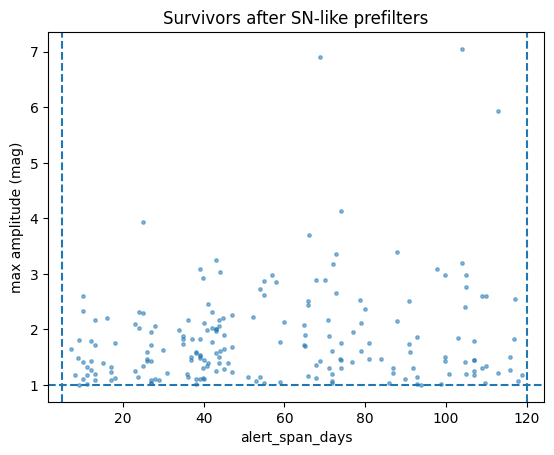

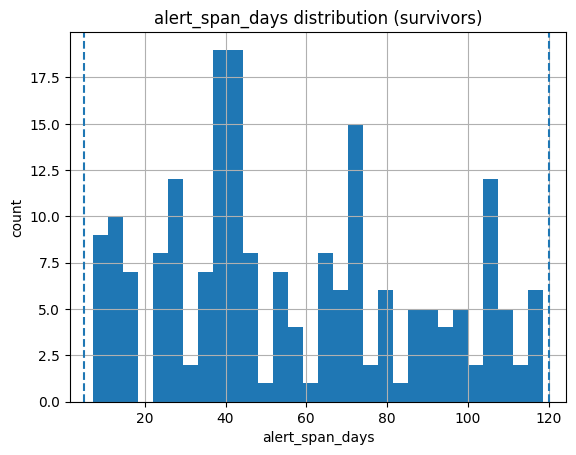

In [140]:
import matplotlib.pyplot as plt

# Safe access to columns (handles case differences)
def get_col(df, name):
    for c in df.columns:
        if c.lower() == name.lower():
            return c
    raise KeyError(f"Column {name} not found")

g_amp_col   = get_col(df, "g_amplitude")
r_amp_col   = get_col(df, "r_amplitude")
span_col    = get_col(df, "alert_span_days")
color_col   = next((c for c in df.columns if c.lower() == "mean_g-r"), None)

amp_max = df[[g_amp_col, r_amp_col]].max(axis=1, skipna=True)

# Scatter: amplitude vs span (survivors only)
plt.figure()
plt.scatter(df[span_col], amp_max, s=6, alpha=0.5)
plt.axvline(5, linestyle="--")
plt.axvline(120, linestyle="--")
plt.axhline(1.0, linestyle="--")
plt.xlabel("alert_span_days")
plt.ylabel("max amplitude (mag)")
plt.title("Survivors after SN-like prefilters")
plt.show()

# (Optional) Histogram of span among survivors
plt.figure()
df[span_col].hist(bins=30)
plt.axvline(5, linestyle="--")
plt.axvline(120, linestyle="--")
plt.xlabel("alert_span_days")
plt.ylabel("count")
plt.title("alert_span_days distribution (survivors)")
plt.show()


### Results without cut on 200 days

In [34]:
# Extract name/id
row = df.loc[df["objName"] == "PSO J128.9117-04.0883", ["objName", "ZTFID"]]
print(row)
row = df.loc[df["objName"] == "PSO J283.6976+55.3976", ["objName", "ZTFID"]]
print(row)
row = df.loc[df["objName"] == "PSO J337.1748+43.2297", ["objName", "ZTFID"]]
print(row)
row = df.loc[df["objName"] == "PSO J115.6368+49.8097", ["objName", "ZTFID"]]
print(row)



                   objName         ZTFID
925  PSO J128.9117-04.0883  ZTF18acgvhxo
                   objName         ZTFID
225  PSO J283.6976+55.3976  ZTF18aanuzde
                    objName         ZTFID
1448  PSO J337.1748+43.2297  ZTF19aawevyv
                  objName         ZTFID
63  PSO J115.6368+49.8097  ZTF18aabilqu


In [36]:
# Split anomalies by features_valid

# Valid anomalies (features_valid == true)
valid_anomalies = (
    preview[preview["features_valid"] == True]
    .sort_values("iso_rank")
    .reset_index(drop=True)
)

# Unreliable anomalies 
invalid_anomalies = (
    preview[preview["features_valid"] == False]
    .sort_values("iso_rank")
    .reset_index(drop=True)
)

# Show top 10 from each
print("Top 10 valid anomalies:")
display(valid_anomalies.head(10))

print("Top 10 strange anomalies:")
display(invalid_anomalies.head(10))

# Save separately
valid_anomalies.to_csv("reference_20k_valid_anomalies.csv", index=False)
invalid_anomalies.to_csv("reference_20k_invalid_anomalies.csv", index=False)


Top 10 valid anomalies:


,ZTFID,t0,r_duration_above_half_flux,g_peak_mag,r_peak_mag,mean_g-r,features_valid,r_duration_above_half_flux,iso_score,iso_anomaly,iso_rank
0,ZTF18aabilqu,58360.513079,2208.998079,15.248654,14.825365,0.808560,True,2208.998079,-0.212265,1,10
1,ZTF18abjhbss,58322.424942,1913.823275,17.262716,16.456707,0.578618,True,1913.823275,-0.210216,1,12
2,ZTF18abtvajf,58368.229873,1561.892824,17.080242,16.883101,1.151374,True,1561.892824,-0.209298,1,14
3,ZTF18adisfiy,58252.413067,2062.203727,16.432600,16.021099,0.525252,True,2062.203727,-0.207879,1,16
4,ZTF19aadnhaw,58883.242176,1841.182951,15.795343,15.998410,-0.149093,True,1841.182951,-0.207361,1,17
5,ZTF18aaqzomm,58252.411609,2399.220775,17.181522,17.578285,-0.164648,True,2399.220775,-0.205367,1,18
6,ZTF18acvgzbp,58472.443588,1480.996991,14.932600,14.918000,0.058028,True,1480.996991,-0.203664,1,21
7,ZTF18abgoodz,58312.473831,2329.770058,16.842958,16.490053,0.367807,True,2329.770058,-0.200743,1,26
8,ZTF18abacxpl,58281.407951,1576.330938,17.313900,17.428900,-0.150926,True,1576.330938,-0.195991,1,30
9,ZTF20acxhear,58456.247141,2073.317847,17.401100,16.331100,1.483282,True,2073.317847,-0.195324,1,32


Top 10 strange anomalies:


,ZTFID,t0,r_duration_above_half_flux,g_peak_mag,r_peak_mag,mean_g-r,features_valid,r_duration_above_half_flux,iso_score,iso_anomaly,iso_rank
0,ZTF18ablqsov,58669.283854,1554.922824,16.045099,16.252300,-0.437946,False,1554.922824,-0.253933,1,1
1,ZTF18aalataf,58612.446134,1951.855185,16.848600,17.090679,-1.598087,False,1951.855185,-0.248612,1,2
2,ZTF18abnuekr,58644.460532,1953.669410,17.057899,17.020267,-0.460937,False,1953.669410,-0.247273,1,3
3,ZTF18aaapjfq,58360.514526,2429.651643,16.538094,17.262501,0.315912,False,2429.651643,-0.242008,1,4
4,ZTF18ablwvcy,58344.348553,2438.200417,17.004261,17.659700,0.103281,False,2438.200417,-0.235605,1,5
5,ZTF18acxbexw,58557.360741,2199.962095,16.414274,16.488100,-0.120146,False,2199.962095,-0.233004,1,6
6,ZTF18acgvhxo,58435.521215,2333.845278,16.100832,15.568569,0.255854,False,2333.845278,-0.221767,1,7
7,ZTF18aanuzde,58252.491157,2533.963877,16.863199,17.648199,-0.439563,False,2533.963877,-0.219895,1,8
8,ZTF19aawevyv,58634.426979,1763.092951,17.891172,17.878672,0.990386,False,1763.092951,-0.215577,1,9
9,ZTF18aagpxsx,58471.276400,2215.982072,16.901436,17.032700,-0.094638,False,2215.982072,-0.210590,1,11


The following blocks are looking at number of anomalies found to see what is going on with features_valid

In [38]:
print(out["iso_anomaly"].value_counts())
print(out["iso_anomaly"].value_counts(normalize=True))  # fraction


iso_anomaly
0    23914
1     1601
Name: count, dtype: int64
iso_anomaly
0    0.937253
1    0.062747
Name: proportion, dtype: float64


In [39]:
print(pd.crosstab(preview["features_valid"], preview["iso_anomaly"]))


iso_anomaly         0     1
features_valid             
False           17715  1105
True             6199   496


In [40]:
if "best_cat" in df.columns:
    print(pd.crosstab(df["best_cat"], out["iso_anomaly"]))


iso_anomaly      0     1
best_cat                
panstarrs    20253  1554


In [41]:
print([c for c in df.columns if "tns" in c.lower() or "cat" in c.lower()])


['best_cat', 'best_cat_release', 'missedcat_posterior', 'extra_cat_cols', 'iExtNSigma', 'gExtNSigma', 'rExtNSigma', 'yExtNSigma', 'zExtNSigma', 'tns_redshift']


In [42]:
if "best_cat" in df.columns:
    print(pd.crosstab(df["best_cat"], out["iso_anomaly"]))


iso_anomaly      0     1
best_cat                
panstarrs    20253  1554


### Isolation Forest with different contamination:

In [53]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.1,   # use auto for first run
    random_state=42,
    n_jobs=-1
)
iso.fit(X_imp)

scores   = iso.decision_function(X_imp)  # higher = more normal
raw_pred = iso.predict(X_imp)            # -1 anomaly, 1 normal
anomaly  = (raw_pred == -1).astype(int)  # 1 = anomaly

rank = pd.Series(scores).rank(method="first", ascending=True).astype(int)  # 1 = most anomalous

print("Estimated anomaly rate:", anomaly.mean())

Estimated anomaly rate: 0.1000195963158926


In [54]:
out = pd.DataFrame({
    "objName": df["objName"].values,
    "iso_score": scores,
    "iso_anomaly": anomaly,
    "iso_rank": rank
})

# Optional context columns if present
context_cols = [c for c in ["t0","g_peak_mag","r_peak_mag","mean_g-r","features_valid"] if c in df.columns]
preview = pd.concat([df[["objName"] + context_cols].reset_index(drop=True),
                     out[["iso_score","iso_anomaly","iso_rank"]]], axis=1)

# Show 10 most anomalous
display(preview.sort_values("iso_rank").head(10))


,objName,t0,g_peak_mag,r_peak_mag,mean_g-r,features_valid,iso_score,iso_anomaly,iso_rank
518,PSO J275.9690+23.5268,58669.283854,16.045099,16.252300,-0.437946,False,-0.312751,1,1
185,PSO J275.6485+41.8038,58612.446134,16.848600,17.090679,-1.598087,False,-0.307429,1,2
544,PSO J303.4828-05.4350,58644.460532,17.057899,17.020267,-0.460937,False,-0.306090,1,3
42,PSO J109.8504+29.3950,58360.514526,16.538094,17.262501,0.315912,False,-0.300825,1,4
529,PSO J289.7529+36.0261,58344.348553,17.004261,17.659700,0.103281,False,-0.294422,1,5
1068,PSO J213.7545-09.2659,58557.360741,16.414274,16.488100,-0.120146,False,-0.291821,1,6
925,PSO J128.9117-04.0883,58435.521215,16.100832,15.568569,0.255854,False,-0.280584,1,7
225,PSO J283.6976+55.3976,58252.491157,16.863199,17.648199,-0.439563,False,-0.278712,1,8
1448,PSO J337.1748+43.2297,58634.426979,17.891172,17.878672,0.990386,False,-0.274395,1,9
63,PSO J115.6368+49.8097,58360.513079,15.248654,14.825365,0.808560,True,-0.271082,1,10


In [57]:
# Split anomalies by features_valid

# Valid anomalies (features_valid == true)
valid_anomalies = (
    preview[preview["features_valid"] == True]
    .sort_values("iso_rank")
    .reset_index(drop=True)
)

# Unreliable anomalies 
invalid_anomalies = (
    preview[preview["features_valid"] == False]
    .sort_values("iso_rank")
    .reset_index(drop=True)
)

# Show top 10 from each
print("Top 10 valid anomalies:")
display(valid_anomalies.head(10))

print("Top 10 strange anomalies:")
display(invalid_anomalies.head(10))

# Save separately
valid_anomalies.to_csv("reference_20k_valid_anomalies.csv", index=False)
invalid_anomalies.to_csv("reference_20k_invalid_anomalies.csv", index=False)


Top 10 valid anomalies:


,objName,t0,g_peak_mag,r_peak_mag,mean_g-r,features_valid,iso_score,iso_anomaly,iso_rank
0,PSO J115.6368+49.8097,58360.513079,15.248654,14.825365,0.808560,True,-0.271082,1,10
1,PSO J307.0327+22.3902,58322.424942,17.262716,16.456707,0.578618,True,-0.269033,1,12
2,PSO J292.0967-13.3364,58368.229873,17.080242,16.883101,1.151374,True,-0.268115,1,14
3,PSO J278.5756+31.6068,58252.413067,16.432600,16.021099,0.525252,True,-0.266696,1,16
4,PSO J152.9325+57.3038,58883.242176,15.795343,15.998410,-0.149093,True,-0.266178,1,17
5,PSO J284.6753+44.0967,58252.411609,17.181522,17.578285,-0.164648,True,-0.264184,1,18
6,PSO J155.4177-03.4538,58472.443588,14.932600,14.918000,0.058028,True,-0.262481,1,21
7,PSO J010.9273+37.4222,58312.473831,16.842958,16.490053,0.367807,True,-0.259561,1,26
8,PSO J293.8673+53.7628,58281.407951,17.313900,17.428900,-0.150926,True,-0.254808,1,30
9,PSO J092.9730-06.1507,58456.247141,17.401100,16.331100,1.483282,True,-0.254141,1,32


Top 10 strange anomalies:


,objName,t0,g_peak_mag,r_peak_mag,mean_g-r,features_valid,iso_score,iso_anomaly,iso_rank
0,PSO J275.9690+23.5268,58669.283854,16.045099,16.252300,-0.437946,False,-0.312751,1,1
1,PSO J275.6485+41.8038,58612.446134,16.848600,17.090679,-1.598087,False,-0.307429,1,2
2,PSO J303.4828-05.4350,58644.460532,17.057899,17.020267,-0.460937,False,-0.306090,1,3
3,PSO J109.8504+29.3950,58360.514526,16.538094,17.262501,0.315912,False,-0.300825,1,4
4,PSO J289.7529+36.0261,58344.348553,17.004261,17.659700,0.103281,False,-0.294422,1,5
5,PSO J213.7545-09.2659,58557.360741,16.414274,16.488100,-0.120146,False,-0.291821,1,6
6,PSO J128.9117-04.0883,58435.521215,16.100832,15.568569,0.255854,False,-0.280584,1,7
7,PSO J283.6976+55.3976,58252.491157,16.863199,17.648199,-0.439563,False,-0.278712,1,8
8,PSO J337.1748+43.2297,58634.426979,17.891172,17.878672,0.990386,False,-0.274395,1,9
9,PSO J112.5001+11.0348,58471.276400,16.901436,17.032700,-0.094638,False,-0.269408,1,11


In [59]:
print(out["iso_anomaly"].value_counts())
print(out["iso_anomaly"].value_counts(normalize=True))  # fraction


iso_anomaly
0    22963
1     2552
Name: count, dtype: int64
iso_anomaly
0    0.89998
1    0.10002
Name: proportion, dtype: float64


In [61]:
df["best_cat_release"].value_counts().head(20)


best_cat_release
dr2    21807
Name: count, dtype: int64

In [63]:
[c for c in df.columns if "tns" in c.lower() or "class" in c.lower()]


['iExtNSigma',
 'gExtNSigma',
 'rExtNSigma',
 'yExtNSigma',
 'zExtNSigma',
 'tns_redshift']

As we are getting quasars and AGNs, we need to refine features to target anomalous supernovae. Here we will inspect features used and see what we can remove by hand. 

In [66]:
# List column names
headers = df.columns.tolist()
print(headers)

# Just see the first 20 headers
print(df.columns[:20])

# columns total
print("Number of columns:", len(df.columns))


['t0', 'g_peak_mag', 'g_peak_time', 'g_rise_time', 'g_decline_time', 'g_duration_above_half_flux', 'g_amplitude', 'g_skewness', 'g_beyond_2sigma', 'r_peak_mag', 'r_peak_time', 'r_rise_time', 'r_decline_time', 'r_duration_above_half_flux', 'r_amplitude', 'r_skewness', 'r_beyond_2sigma', 'mean_g-r', 'g-r_at_g_peak', 'mean_color_rate', 'g_n_peaks', 'g_dt_main_to_secondary_peak', 'g_dmag_secondary_peak', 'g_secondary_peak_prominence', 'g_secondary_peak_width', 'r_n_peaks', 'r_dt_main_to_secondary_peak', 'r_dmag_secondary_peak', 'r_secondary_peak_prominence', 'r_secondary_peak_width', 'g_max_rolling_variance', 'g_mean_rolling_variance', 'r_max_rolling_variance', 'r_mean_rolling_variance', 'g_rise_local_curvature', 'g_decline_local_curvature', 'r_rise_local_curvature', 'r_decline_local_curvature', 'features_valid', 't0_err', 'g_peak_mag_err', 'g_peak_time_err', 'g_rise_time_err', 'g_decline_time_err', 'g_duration_above_half_flux_err', 'g_amplitude_err', 'g_skewness_err', 'g_beyond_2sigma_err

Now, get rid of lc with r_duration_above_half_flux longer than 2 years. r_duration_above_half_flux > 781

In [69]:
csv_path = "/Users/jennakempster-taylor/re-laiss/reference_20k.csv" 

# Load
df = pd.read_csv(csv_path, low_memory=False)

# Ensure there is an object name column
if "objName" not in df.columns:
    # Some variants may include "NAME" or similar,, map it if present
    for candidate in ["NAME", "name", "ObjName", "object_name"]:
        if candidate in df.columns:
            df = df.rename(columns={candidate: "objName"})
            break

if "objName" not in df.columns:
    raise ValueError("Could not find 'objName' in the CSV. ")

print("Shape:", df.shape)
print("Columns:", df.columns[:10])  # first 10 columns
print("First few objNames:", df["objName"].head())

default_lc_features = constants.lc_features_const.copy()
default_host_features = constants.host_features_const.copy()

from pprint import pprint

USE_HOST = False  # use only light curves initially

def overlap(cols, frame):
    return [c for c in cols if (c in frame.columns) and (not c.endswith("_err"))]

lc_cols   = overlap(default_lc_features, df)
host_cols = overlap(default_host_features, df) if USE_HOST else []

feature_cols = lc_cols + host_cols

print(f"Found {len(lc_cols)} LC features in CSV.")
if USE_HOST:
    print(f"Found {len(host_cols)} host features in CSV.")
print(f"Total features used: {len(feature_cols)}")
pprint(feature_cols[:15])

from sklearn.impute import SimpleImputer

X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

# Quick look at missingness
missing_pct = X.isna().mean().sort_values(ascending=False)
print("Top 10 columns by missing rate:")
print(missing_pct.head(10))

#imp = SimpleImputer(strategy="median")
#X_imp = imp.fit_transform(X)

print("X shape:", X.shape, " -> after impute:", X_imp.shape)

from sklearn.impute import KNNImputer

X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

#  missing value is filled in using  mean of 5 nearest neighbors
knn_imp = KNNImputer(n_neighbors=5, weights="uniform")
X_imp = knn_imp.fit_transform(X)

print("X shape:", X.shape, " -> after KNN impute:", X_imp.shape)




Shape: (25515, 458)
Columns: Index(['t0', 'g_peak_mag', 'g_peak_time', 'g_rise_time', 'g_decline_time',
       'g_duration_above_half_flux', 'g_amplitude', 'g_skewness',
       'g_beyond_2sigma', 'r_peak_mag'],
      dtype='object')
First few objNames: 0    PSO J032.5595-01.8136
1    PSO J118.7364+35.9410
2    PSO J158.8836+37.6496
3    PSO J031.2821+11.2486
4    PSO J105.8641+32.0687
Name: objName, dtype: object
Found 25 LC features in CSV.
Total features used: 25
['g_peak_time',
 'r_peak_time',
 'g_rise_time',
 'g_decline_time',
 'r_rise_time',
 'r_decline_time',
 'g_duration_above_half_flux',
 'r_duration_above_half_flux',
 'g_amplitude',
 'r_amplitude',
 'g_skewness',
 'r_skewness',
 'g_beyond_2sigma',
 'r_beyond_2sigma',
 'mean_g-r']
Top 10 columns by missing rate:
g_rise_local_curvature        0.420419
r_rise_local_curvature        0.389183
r_decline_local_curvature     0.347443
g_decline_local_curvature     0.324005
g_rise_time                   0.264511
r_rise_time             

In [70]:
# Filter out non-SN lightcurves

DUR_CUTOFF = 731  # days

if "r_duration_above_half_flux" not in df.columns:
    raise KeyError("r_duration_above_half_flux not found in df.columns")

n_before = len(df)
# mask_keep = (df["r_duration_above_half_flux"].notna()) & (df["r_duration_above_half_flux"] <= DUR_CUTOFF)
# If you also want to keep rows with NaN durations, change to:
mask_keep = (df["r_duration_above_half_flux"].isna()) | (df["r_duration_above_half_flux"] <= DUR_CUTOFF)

df_filt = df[mask_keep].copy()
n_after = len(df_filt)
print(f"Filtered by r_duration_above_half_flux <= {DUR_CUTOFF} days: kept {n_after}/{n_before} "
      f"({n_after/n_before:.1%}); removed {n_before-n_after}")

# save the removed objects for audit
removed = df[~mask_keep][["objName","ZTFID","r_duration_above_half_flux"]].copy()
removed.to_csv("removed_long_duration_objects.csv", index=False)
print("Saved removed_long_duration_objects.csv")


Filtered by r_duration_above_half_flux <= 731 days: kept 24277/25515 (95.1%); removed 1238
Saved removed_long_duration_objects.csv


In [71]:
# Use df_filt from here on 
# 1 Features on the filtered frame
lc_cols   = [c for c in default_lc_features if (c in df_filt.columns) and (not c.endswith("_err"))]
host_cols = []  # add host features later if you like
feature_cols = lc_cols + host_cols

X = df_filt[feature_cols].replace([np.inf, -np.inf], np.nan)

# 2 Impute (KNN) on the FILTERED X
from sklearn.impute import KNNImputer
knn_imp = KNNImputer(n_neighbors=5, weights="uniform")
X_imp = knn_imp.fit_transform(X)

print("Shapes -> df_filt:", df_filt.shape, " X:", X.shape, " X_imp:", X_imp.shape)

# 3 Isolation Forest on the FILTERED, IMPUTED matrix
from sklearn.ensemble import IsolationForest
iso = IsolationForest(n_estimators=300, contamination="auto", random_state=42, n_jobs=-1)
iso.fit(X_imp)

import pandas as pd
scores   = iso.decision_function(X_imp)   # length == len(df_filt)
raw_pred = iso.predict(X_imp)
anomaly  = (raw_pred == -1).astype(int)
rank     = pd.Series(scores, index=df_filt.index).rank(method="first", ascending=True).astype(int)

# 4 Pack results (ensure lengths match)
assert len(scores) == len(df_filt), "Length mismatch: scores vs df_filt"

out = pd.DataFrame({
    "ZTFID":      df_filt["ZTFID"].values,
    "iso_score":  scores,
    "iso_anomaly": anomaly,
    "iso_rank":   rank.values
}, index=df_filt.index)

# 5 Build preview from the FILTERED df only
context_cols = [c for c in ["t0","r_duration_above_half_flux","g_peak_mag","r_peak_mag","mean_g-r","features_valid","ZTFID"] 
                if c in df_filt.columns]

preview = pd.concat(
    [df_filt[["ZTFID"] + context_cols], out[["iso_score","iso_anomaly","iso_rank"]]],
    axis=1
)

display(preview.sort_values("iso_rank").head(10))

# sanity checks
print("\nAnomaly rate:", out["iso_anomaly"].mean())
print("Value counts:\n", out["iso_anomaly"].value_counts())



Shapes -> df_filt: (24277, 458)  X: (24277, 25)  X_imp: (24277, 25)


,ZTFID,t0,r_duration_above_half_flux,g_peak_mag,r_peak_mag,mean_g-r,features_valid,ZTFID,iso_score,iso_anomaly,iso_rank
1076,ZTF18acxhkka,58801.093773,337.052558,17.020300,17.324699,-0.103537,False,ZTF18acxhkka,-0.223540,1,1
821,ZTF18accdrut,58572.178021,14.024410,17.252394,16.766460,0.256936,False,ZTF18accdrut,-0.220958,1,2
760,ZTF18abxyyiv,58427.170347,NaN,15.836356,15.253467,0.571024,False,ZTF18abxyyiv,-0.220774,1,3
600,ZTF18abrzhyq,58362.208206,363.003611,17.256380,16.221001,0.282026,False,ZTF18abrzhyq,-0.218584,1,4
1103,ZTF18aczepge,58472.522963,NaN,19.108257,17.066900,0.750584,False,ZTF18aczepge,-0.218181,1,5
1080,ZTF18acxzvwr,58469.504919,470.746944,15.869750,15.136362,0.966428,True,ZTF18acxzvwr,-0.217722,1,6
1820,ZTF20aakntgv,58657.199745,475.803368,14.244300,13.696800,1.159959,False,ZTF20aakntgv,-0.213958,1,7
1863,ZTF20aaodweh,58964.442465,198.666713,16.694000,16.846212,-0.153226,True,ZTF20aaodweh,-0.212549,1,8
1470,ZTF19aaysjah,58645.272766,380.034583,15.704500,15.242000,0.490126,False,ZTF19aaysjah,-0.211914,1,9
108,ZTF18aagoxll,58486.453472,597.759664,17.290001,17.453300,0.105582,False,ZTF18aagoxll,-0.211125,1,10



Anomaly rate: 0.04695802611525312
Value counts:
 iso_anomaly
0    23137
1     1140
Name: count, dtype: int64


In [72]:
# All column headers
all_cols = df.columns.tolist()
print("Number of columns:", len(all_cols))
print("First 20 columns:", all_cols[:20])


Number of columns: 458
First 20 columns: ['t0', 'g_peak_mag', 'g_peak_time', 'g_rise_time', 'g_decline_time', 'g_duration_above_half_flux', 'g_amplitude', 'g_skewness', 'g_beyond_2sigma', 'r_peak_mag', 'r_peak_time', 'r_rise_time', 'r_decline_time', 'r_duration_above_half_flux', 'r_amplitude', 'r_skewness', 'r_beyond_2sigma', 'mean_g-r', 'g-r_at_g_peak', 'mean_color_rate']


In [73]:
pd.Series(df.columns).to_csv("reference_20k_headers.csv", index=False)
print("Saved headers to reference_20k_headers.csv")


Saved headers to reference_20k_headers.csv


In [74]:

from scipy.stats import spearmanr

feat_df = df_filt[feature_cols].copy()
feat_df = feat_df.replace([np.inf,-np.inf], np.nan)
feat_df = pd.DataFrame(X_imp, columns=feature_cols, index=df_filt.index)  # imputed version

def spearman_to_score(col):
    v = feat_df[col].values
    m = np.isfinite(v) & np.isfinite(scores)
    r, p = spearmanr(v[m], scores[m])
    return r, p

corrs = pd.DataFrame({f: spearman_to_score(f) for f in feature_cols}, index=["rho","p"]).T
corrs_sorted = corrs.sort_values("rho")  # most negative -> more anomalous when feature is large
corrs_sorted.head(15)


,rho,p
r_max_rolling_variance,-0.509038,0.0
g_max_rolling_variance,-0.493129,0.0
r_beyond_2sigma,-0.476740,0.0
g_peak_time,-0.469244,0.0
g_beyond_2sigma,-0.468100,0.0
r_mean_rolling_variance,-0.466128,0.0
g_duration_above_half_flux,-0.456143,0.0
g_mean_rolling_variance,-0.442868,0.0
r_duration_above_half_flux,-0.441438,0.0
r_peak_time,-0.422878,0.0


In [75]:
transient_features = [
    "g_peak_mag","r_peak_mag",
    "g_amplitude","r_amplitude",
    "g_rise_time","r_rise_time",
    "g_decline_time","r_decline_time",
    "g_skewness","r_skewness",
    "g_n_peaks","r_n_peaks",
    "mean_g-r","g-r_at_g_peak","mean_color_rate",
    "g_beyond_2sigma","r_beyond_2sigma"
]

# Keep only features that actually exist in your df
transient_cols = [c for c in transient_features if c in df_filt.columns]

print("Transient-focused features:", len(transient_cols))
print(transient_cols)

Transient-focused features: 17
['g_peak_mag', 'r_peak_mag', 'g_amplitude', 'r_amplitude', 'g_rise_time', 'r_rise_time', 'g_decline_time', 'r_decline_time', 'g_skewness', 'r_skewness', 'g_n_peaks', 'r_n_peaks', 'mean_g-r', 'g-r_at_g_peak', 'mean_color_rate', 'g_beyond_2sigma', 'r_beyond_2sigma']


In [76]:


X_trans = df_filt[transient_cols].replace([np.inf, -np.inf], np.nan)

from sklearn.impute import KNNImputer
knn_imp = KNNImputer(n_neighbors=5)
X_trans_imp = knn_imp.fit_transform(X_trans)

# Train IF 
from sklearn.ensemble import IsolationForest
iso_trans = IsolationForest(n_estimators=300, contamination="auto", random_state=42, n_jobs=-1)
iso_trans.fit(X_trans_imp)

scores_trans   = iso_trans.decision_function(X_trans_imp)
raw_pred_trans = iso_trans.predict(X_trans_imp)
anomaly_trans  = (raw_pred_trans == -1).astype(int)

import pandas as pd
rank_trans = pd.Series(scores_trans, index=df_filt.index).rank(method="first", ascending=True).astype(int)

out_trans = pd.DataFrame({
    "ZTFID": df_filt["ZTFID"].values,
    "iso_score": scores_trans,
    "iso_anomaly": anomaly_trans,
    "iso_rank": rank_trans.values
}, index=df_filt.index)

preview_trans = pd.concat([
    df_filt[["objName","ZTFID","features_valid"]],
    out_trans[["iso_score","iso_anomaly","iso_rank"]]
], axis=1)

display(preview_trans.sort_values("iso_rank").head(10))

,objName,ZTFID,features_valid,iso_score,iso_anomaly,iso_rank
83,PSO J101.0453+35.7790,ZTF18aaenfaa,False,-0.206937,1,1
22605,NaN,ZTF25aacfjde,False,-0.201842,1,2
5039,PSO J258.0762+13.4276,ZTF21aanehlz,False,-0.194582,1,3
39,PSO J205.5349+35.6543,ZTF18aabkvav,True,-0.192374,1,4
940,PSO J053.3283+37.3031,ZTF18achqjmj,True,-0.186527,1,5
1099,PSO J126.2236-09.1440,ZTF18aczdlsx,False,-0.180463,1,6
12254,PSO J114.2562+25.9539,ZTF22abewydn,False,-0.179090,1,7
1820,PSO J221.0549+41.3382,ZTF20aakntgv,False,-0.178623,1,8
1470,PSO J214.8434-26.6448,ZTF19aaysjah,False,-0.176315,1,9
1511,PSO J025.5571+17.9311,ZTF19abegvkv,True,-0.175443,1,10


We will continue to explore what features are needed after looking at the results of this run. It is likely that more refinement is required. 

### Clean Run with Sorted Data

In [185]:
import numpy as np
import pandas as pd
from pprint import pprint
from relaiss import constants
from sklearn.impute import KNNImputer

csv_path = "/Users/jennakempster-taylor/re-laiss/reference_20k.csv"

# Load
df = pd.read_csv(csv_path, low_memory=False)

# Ensure there is an object name column
if "objName" not in df.columns:
    for candidate in ["NAME", "name", "ObjName", "object_name"]:
        if candidate in df.columns:
            df = df.rename(columns={candidate: "objName"})
            break
if "objName" not in df.columns:
    raise ValueError("Could not find 'objName' in the CSV.")

# Grab RELAISS features
default_lc_features   = constants.lc_features_const.copy()
default_host_features = constants.host_features_const.copy()
USE_HOST = False  # use only light curves initially

def overlap(cols, frame):
    # keep only existing, non-error columns
    return [c for c in cols if (c in frame.columns) and (not c.endswith("_err"))]

lc_cols   = overlap(default_lc_features, df)
host_cols = overlap(default_host_features, df) if USE_HOST else []
feature_cols = lc_cols + host_cols

# --- Compute alert span (newest_alert - oldest_alert) ---
REQUIRED = {"newest_alert", "oldest_alert"}
lower_cols = {c.lower(): c for c in df.columns}
missing = REQUIRED - set(lower_cols.keys())
if missing:
    raise ValueError(f"Missing required columns for span filter: {missing}. "
                     "Expected columns 'newest_alert' and 'oldest_alert' (case-insensitive).")

def _find(col_lower):
    return lower_cols[col_lower]

newest_col = _find("newest_alert")
oldest_col = _find("oldest_alert")
newest = df[newest_col]
oldest = df[oldest_col]

if not np.issubdtype(newest.dtype, np.number) or not np.issubdtype(oldest.dtype, np.number):
    newest = pd.to_datetime(newest, errors="coerce", utc=True)
    oldest = pd.to_datetime(oldest, errors="coerce", utc=True)
    span_days = (newest - oldest).dt.total_seconds() / 86400.0
else:
    # Numeric already in days (MJD-style)
    span_days = newest - oldest

df["alert_span_days"] = span_days

# --- Apply instructor cut: keep span < 200 days ---
mask_span = np.isfinite(df["alert_span_days"].values) & (df["alert_span_days"].values < 200)
before, after = len(df), int(mask_span.sum())
print(f"Applying alert-span < 200d: kept {after}/{before} rows ({after/before:.1%}).")
df = df.loc[mask_span].reset_index(drop=True)

# --- Supernova-like prefilters (Amplitude & Duration window) ---
AMPLITUDE_MIN = 1.0   # mag (tunable)
SPAN_MIN_DAYS = 5.0
SPAN_MAX_DAYS = 200
USE_COLOUR_CUT = False
COLOUR_MIN = 0.0

def find_col_case_insensitive(name):
    for c in df.columns:
        if c.lower() == name.lower():
            return c
    return None

required_cols = {
    "g_amplitude": find_col_case_insensitive("g_amplitude"),
    "r_amplitude": find_col_case_insensitive("r_amplitude"),
    "alert_span_days": find_col_case_insensitive("alert_span_days"),
}
optional_cols = {
    "mean_g-r": find_col_case_insensitive("mean_g-r"),
}

missing_req = [k for k, v in required_cols.items() if v is None]
if missing_req:
    raise KeyError("Missing required columns for SN-like prefilters: " + ", ".join(missing_req))

g_amp = df[required_cols["g_amplitude"]]
r_amp = df[required_cols["r_amplitude"]]
span  = df[required_cols["alert_span_days"]]

amp_max = pd.concat([g_amp, r_amp], axis=1).max(axis=1, skipna=True)

mask_sn = (
    amp_max.gt(AMPLITUDE_MIN)
    & span.ge(SPAN_MIN_DAYS)
    & span.le(SPAN_MAX_DAYS)
)

before = len(df)
df = df.loc[mask_sn].reset_index(drop=True)
after = len(df)
print(
    f"SN-like prefilters applied:"
    f"\n  amplitude > {AMPLITUDE_MIN} mag"
    f"\n  {SPAN_MIN_DAYS} <= alert_span_days <= {SPAN_MAX_DAYS}"
)
print(f"Kept {after}/{before} rows ({after/before:.1%}).")

# Build X and impute AFTER
X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

# KNN impute
knn_imp = KNNImputer(n_neighbors=5, weights="uniform")
X_imp = knn_imp.fit_transform(X)

print("X shape (post-filters, pre-impute):", X.shape, " -> X_imp:", X_imp.shape)


Applying alert-span < 200d: kept 1342/25515 rows (5.3%).
SN-like prefilters applied:
  amplitude > 1.0 mag
  5.0 <= alert_span_days <= 200
Kept 228/1342 rows (17.0%).
X shape (post-filters, pre-impute): (228, 25)  -> X_imp: (228, 25)


In [187]:
# Prefer a stable ID column if available
id_candidates = ["ZTFID", "objName", "objectId", "oid"]
ID_COL = next((c for c in id_candidates if c in df.columns), None)
ids = df[ID_COL].astype(str).values if ID_COL else df.index.astype(str).values
id_name = ID_COL if ID_COL else "index"

# --- Fit Isolation Forest ---
iso = IsolationForest(
    n_estimators=300,
    contamination="auto",   # let IF choose threshold from score distribution
    random_state=42,
    n_jobs=-1
)
iso.fit(X_imp)

# Scores, labels, stable rank
scores   = iso.decision_function(X_imp)   # higher = more normal
raw_pred = iso.predict(X_imp)             # -1 anomaly, 1 normal
anomaly  = (raw_pred == -1).astype(int)   # 1 = anomaly

print(f"Estimated anomaly rate: {anomaly.mean():.4f}")

# Stable ranking: 1 = most anomalous (lowest score)
scores_s = pd.Series(scores, index=pd.Index(ids, name=id_name))
order    = scores_s.sort_values(ascending=True, kind="mergesort")  # stable sort
rank_map = pd.Series(np.arange(1, len(order)+1), index=order.index)
iso_rank = rank_map.reindex(scores_s.index).astype(int).values


out = pd.DataFrame({
    id_name: ids,
    "iso_score": scores,
    "iso_anomaly": anomaly,
    "iso_rank": iso_rank
})


context_cols = [c for c in [
    "t0", "r_duration_above_half_flux", "g_peak_mag", "r_peak_mag",
    "mean_g-r", "features_valid", "alert_span_days", "g_amplitude", "r_amplitude"
] if c in df.columns]

left  = (df[[ID_COL] + context_cols].reset_index(drop=True)
         if ID_COL else df[context_cols].reset_index(drop=True))
right = out[["iso_score","iso_anomaly","iso_rank"]].reset_index(drop=True)
preview = pd.concat([left, right], axis=1)

# Show top 10 most anomalous
display(preview.sort_values("iso_rank").head(10))

Estimated anomaly rate: 0.0570


,ZTFID,t0,r_duration_above_half_flux,g_peak_mag,r_peak_mag,mean_g-r,features_valid,alert_span_days,g_amplitude,r_amplitude,iso_score,iso_anomaly,iso_rank
71,ZTF25aacfjde,60694.403900,NaN,13.371340,12.851389,-0.020231,False,103.996968,5.399771,7.051214,-0.179125,1,1
80,ZTF25aaguzft,60729.381088,4.882697,14.344838,12.518044,-0.076079,False,68.782940,5.056161,6.898557,-0.148293,1,2
205,ZTF24abzgdfb,60644.465000,NaN,19.836599,16.160101,0.667206,False,149.774815,0.712900,3.482698,-0.103207,1,3
60,ZTF24absdndj,60619.503866,175.736968,19.576200,19.615829,0.237098,True,194.750752,1.005899,0.639429,-0.067728,1,4
137,ZTF24abpxdiz,60614.536482,157.794502,19.034019,18.700188,0.752456,False,182.721018,1.097780,0.380569,-0.041366,1,5
156,ZTF19aatetvk,60687.504329,107.749815,16.118999,15.341308,1.039580,True,116.767616,1.535677,1.832343,-0.030483,1,6
91,ZTF18aavedgv,60705.556701,83.865428,17.900801,15.723200,2.090896,False,106.885822,1.172600,0.767382,-0.023108,1,7
130,ZTF19acicnua,60659.404861,116.922118,14.589400,13.879600,0.536854,False,138.976887,1.541999,1.787701,-0.013375,1,8
51,ZTF22abhjeea,60614.508576,69.843206,19.282618,18.663601,0.012311,True,183.777199,1.431482,1.532299,-0.012241,1,9
210,ZTF24aboejef,60607.121042,1.967593,16.671329,16.475897,0.227173,False,182.338380,2.882128,0.981703,-0.011754,1,10
